In [11]:
pip install matplotlib

  Using cached matplotlib-3.10.7-cp310-cp310-macosx_11_0_arm64.whl.metadata (11 kB)
  Using cached contourpy-1.3.2-cp310-cp310-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.61.0-cp310-cp310-macosx_10_9_universal2.whl.metadata (113 kB)
  Using cached kiwisolver-1.4.9-cp310-cp310-macosx_11_0_arm64.whl.metadata (6.3 kB)
  Using cached pillow-12.0.0-cp310-cp310-macosx_11_0_arm64.whl.metadata (8.8 kB)
  Using cached pyparsing-3.2.5-py3-none-any.whl.metadata (5.0 kB)
Using cached matplotlib-3.10.7-cp310-cp310-macosx_11_0_arm64.whl (8.1 MB)
Using cached contourpy-1.3.2-cp310-cp310-macosx_11_0_arm64.whl (253 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.61.0-cp310-cp310-macosx_10_9_universal2.whl (2.9 MB)
Using cached kiwisolver-1.4.9-cp310-cp310-macosx_11_0_arm64.whl (65 kB)
Using cached pillow-12.0.0-cp310-cp310-macosx_11_0_arm64.whl (4.7 MB)
Using cached pyparsing-3.2.5-p

In [1]:
import os
import re
import pandas as pd
import matplotlib.pyplot as plt

Scanning directory: ../../data/preprocessed_data ...
Scanning complete. Processed 8901 files.
Data saved to solidity_versions_summary.csv

--- Preview of Data ---


,Dataset_Folder,File_Name,Solidity_Version,Full_Path
0,RE_source3,65.sol,Not Found,../../data/preprocessed_data/RE_source3/contra...
1,RE_source3,1369.sol,Not Found,../../data/preprocessed_data/RE_source3/contra...
2,RE_source3,825.sol,Not Found,../../data/preprocessed_data/RE_source3/contra...
3,RE_source3,71.sol,Not Found,../../data/preprocessed_data/RE_source3/contra...
4,RE_source3,831.sol,Not Found,../../data/preprocessed_data/RE_source3/contra...


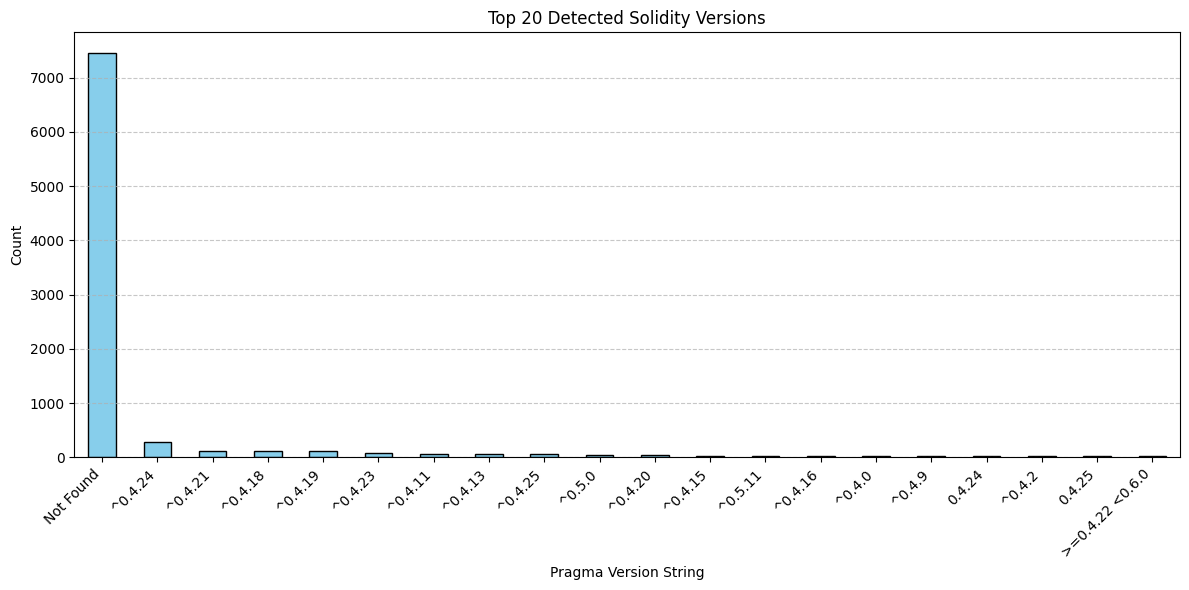


--- Version Distribution Count ---
Solidity_Version
Not Found    7460
^0.4.24       279
^0.4.21       124
^0.4.18       124
^0.4.19       108
             ... 
>=0.4.11        1
^0.4.12         1
0.5.0           1
^ 0.4.17        1
0.4.10          1
Name: count, Length: 71, dtype: int64


In [3]:

# 1. Define the path relative to src/evaluation/
# We go back two levels (../../) to get to the root, then into data
base_path = '../../data/preprocessed_data'

# 2. Define Regex to capture version
# Looks for "pragma solidity" followed by version data, ending with a semicolon
version_pattern = re.compile(r'pragma\s+solidity\s+([^;]+);', re.IGNORECASE)

extracted_data = []

print(f"Scanning directory: {base_path} ...")

# 3. Walk through the directory structure
for root, dirs, files in os.walk(base_path):
    for file in files:
        if file.endswith(".sol"):
            file_path = os.path.join(root, file)
            
            # Extract the parent folder name (The "X" folder)
            # The structure is .../X/contracts/Y.sol
            # splitting the path to get "X" safely
            path_parts = os.path.normpath(file_path).split(os.sep)
            
            # Assuming structure is standard, 'contracts' is usually -2, so X is -3
            try:
                if 'contracts' in path_parts:
                    contract_index = path_parts.index('contracts')
                    dataset_folder = path_parts[contract_index - 1]
                else:
                    # Fallback if 'contracts' folder isn't explicitly there
                    dataset_folder = path_parts[-2] 
            except:
                dataset_folder = "Unknown"

            sol_version = "Not Found"

            try:
                with open(file_path, 'r', encoding='utf-8', errors='ignore') as f:
                    content = f.read()
                    match = version_pattern.search(content)
                    if match:
                        sol_version = match.group(1).strip()
            except Exception as e:
                print(f"Error reading {file}: {e}")

            extracted_data.append({
                'Dataset_Folder': dataset_folder,
                'File_Name': file,
                'Solidity_Version': sol_version,
                'Full_Path': file_path
            })

# 4. Create DataFrame and Save
df = pd.DataFrame(extracted_data)

# Save to CSV in the current directory (src/evaluation)
output_csv = 'solidity_versions_summary.csv'
df.to_csv(output_csv, index=False)

print(f"Scanning complete. Processed {len(df)} files.")
print(f"Data saved to {output_csv}")

# 5. Display Table (Head)
print("\n--- Preview of Data ---")
display(df.head())

# 6. Plotting
plt.figure(figsize=(12, 6))

# Count the versions
version_counts = df['Solidity_Version'].value_counts().head(20) # Top 20 versions

# Create Bar Plot
version_counts.plot(kind='bar', color='skyblue', edgecolor='black')

plt.title('Top 20 Detected Solidity Versions')
plt.xlabel('Pragma Version String')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()

# Optional: Print simple count table
print("\n--- Version Distribution Count ---")
print(df['Solidity_Version'].value_counts())

## modified version:

In [2]:
import os
import re
import pandas as pd

# 1. Define the path relative to src/evaluation/
base_path = '../../data/preprocessed_data'

# 2. Improved Regex
# - \s* instead of \s+ after solidity to handle 'pragma solidity^0.4.0'
# - Case insensitive
version_pattern = re.compile(r'pragma\s+solidity\s*([^;]+?);', re.IGNORECASE)

extracted_data = []
not_found_samples = []

print(f"Scanning directory: {base_path} ...")

# 3. Walk through the directory structure
for root, dirs, files in os.walk(base_path):
    for file in files:
        if file.endswith(".sol"):
            file_path = os.path.join(root, file)
            
            # Extract dataset folder logic (kept from your original script)
            path_parts = os.path.normpath(file_path).split(os.sep)
            try:
                if 'contracts' in path_parts:
                    contract_index = path_parts.index('contracts')
                    dataset_folder = path_parts[contract_index - 1]
                else:
                    dataset_folder = path_parts[-2] 
            except:
                dataset_folder = "Unknown"

            sol_version = "Not Found"
            content_snippet = ""

            try:
                # Try UTF-8 first
                try:
                    with open(file_path, 'r', encoding='utf-8') as f:
                        content = f.read()
                except UnicodeDecodeError:
                    # Fallback to latin-1 for older/mixed encodings
                    with open(file_path, 'r', encoding='latin-1') as f:
                        content = f.read()

                match = version_pattern.search(content)
                if match:
                    sol_version = match.group(1).strip()
                else:
                    # Save a snippet to debug later
                    content_snippet = content[:200].replace('\n', ' ')
            except Exception as e:
                print(f"Error reading {file}: {e}")

            extracted_data.append({
                'Dataset_Folder': dataset_folder,
                'File_Name': file,
                'Solidity_Version': sol_version,
                'Full_Path': file_path
            })
            
            # Collect a few samples of "Not Found" to help debugging
            if sol_version == "Not Found" and len(not_found_samples) < 5:
                not_found_samples.append(f"{file} ({dataset_folder}): {content_snippet}")

# 4. Create DataFrame and Save
df = pd.DataFrame(extracted_data)
output_csv = 'solidity_versions_summary_v2.csv'
df.to_csv(output_csv, index=False)

print(f"Scanning complete. Processed {len(df)} files.")
print(f"Data saved to {output_csv}")

# 5. Debug Output
print("\n--- Summary of Detection ---")
print(df['Solidity_Version'].value_counts().head(10))

print("\n--- Debug: First 5 files where version was NOT found ---")
# This will show you if the files are empty, missing pragmas, or just weirdly formatted
for sample in not_found_samples:
    print(f"[MISSING] {sample}")

Scanning directory: ../../data/preprocessed_data ...
Scanning complete. Processed 8901 files.
Data saved to solidity_versions_summary_v2.csv

--- Summary of Detection ---
Solidity_Version
Not Found    7451
^0.4.24       285
^0.4.21       124
^0.4.18       124
^0.4.19       108
^0.4.23        81
^0.4.11        62
^0.4.13        59
^0.4.25        57
^0.5.0         46
Name: count, dtype: int64

--- Debug: First 5 files where version was NOT found ---
[MISSING] 65.sol (RE_source3): contract Delegate {    address public owner;    function Delegate(address _owner) {     owner = _owner;   }    function pwn() {     owner = msg.sender;   } }  
[MISSING] 1369.sol (RE_source3): contract TokenPoolList {   address[] public list;    event Added(address x);    function add(address x) {     list.push(x);     Added(x);   }    function getCount() public constant returns(uint) {    
[MISSING] 825.sol (RE_source3): contract ABToken is ABStandardToken {      /* Public variables of the token */      /*     

In [5]:
import os
import re
import shutil

# Get the directory where this script is located (src/evaluation)
try:
    # This works when running as a standard script (e.g., python script.py)
    script_dir = os.path.dirname(os.path.abspath(__file__))
except NameError:
    # This works in Jupyter Notebooks where __file__ is not defined
    # IMPORTANT: Assumes the notebook is currently running in src/evaluation
    script_dir = os.getcwd()

# --- CONFIGURATION ---
# The root directory where your data is located
# Resolves to: src/evaluation/../../data/preprocessed_data -> data/preprocessed_data
base_path = os.path.join(script_dir, '../../data/preprocessed_data')

# The destination folder where files WITHOUT pragma will be copied
# Resolves to: src/evaluation/no_pragma_contracts
destination_path = os.path.join(script_dir, 'no_pragma_contracts')

# Regex to detect if pragma exists (Case insensitive, handles flexible spacing)
version_pattern = re.compile(r'pragma\s+solidity\s*([^;]+?);', re.IGNORECASE)

# --- INFERRED VERSION MAP ---
# Based on syntax analysis (emit, constructor style, view/pure, assert/require)
version_map = {
    'IoU': '^0.4.11',
    'RE': '^0.4.11',
    'TD': '^0.4.24',
    'TD_source3': '^0.4.24',
    'RE_source3': '^0.4.24',
    'IoU_source3': '^0.4.24',
    'RE_full_source2_218': '^0.4.11',
    'smartbugs_RE': '^0.4.19',
    # Adding known safe defaults for others if encountered without pragma
    'TD_ESC': '^0.4.24', 
    'RE_smartbugs': '^0.4.19' 
}

def copy_missing_pragma_files(src_dir, dest_dir):
    # Normalize paths
    src_dir = os.path.normpath(src_dir)
    dest_dir = os.path.normpath(dest_dir)

    # Create main destination directory if it doesn't exist
    if not os.path.exists(dest_dir):
        os.makedirs(dest_dir)
        print(f"Created main destination folder: {dest_dir}")
    else:
        print(f"Main destination folder exists: {dest_dir}")

    files_copied_count = 0
    files_scanned_count = 0

    print(f"Scanning {src_dir} ...")

    for root, dirs, files in os.walk(src_dir):
        for file in files:
            if file.endswith(".sol"):
                files_scanned_count += 1
                file_path = os.path.join(root, file)
                
                # Determine the dataset folder name (e.g., RE_source3, IoU, etc.)
                path_parts = os.path.normpath(file_path).split(os.sep)
                try:
                    if 'contracts' in path_parts:
                        c_index = path_parts.index('contracts')
                        dataset_folder = path_parts[c_index - 1]
                    else:
                        # Fallback logic if 'contracts' isn't explicitly in path
                        dataset_folder = path_parts[-2]
                except:
                    dataset_folder = "Unknown"

                has_pragma = False

                try:
                    # Try reading with UTF-8 first, fallback to Latin-1
                    try:
                        with open(file_path, 'r', encoding='utf-8') as f:
                            content = f.read()
                    except UnicodeDecodeError:
                        with open(file_path, 'r', encoding='latin-1') as f:
                            content = f.read()
                    
                    # Check for pragma
                    if version_pattern.search(content):
                        has_pragma = True
                    
                except Exception as e:
                    print(f"Error reading {file}: {e}")
                    continue

                # COPY IF NO PRAGMA FOUND
                if not has_pragma:
                    # Determine the inferred version folder
                    inferred_version = version_map.get(dataset_folder, "Unknown_Version")

                    # Define the specific subfolder: dest / version / dataset
                    # e.g. src/evaluation/no_pragma_contracts/^0.4.24/RE_source3/
                    specific_dest_dir = os.path.join(dest_dir, inferred_version, dataset_folder)
                    
                    # Create this subfolder if it doesn't exist
                    if not os.path.exists(specific_dest_dir):
                        os.makedirs(specific_dest_dir)

                    # Keep original filename
                    dest_file_path = os.path.join(specific_dest_dir, file)
                    
                    try:
                        shutil.copy2(file_path, dest_file_path)
                        files_copied_count += 1
                        
                        # Optional: Print every 100th file to show progress
                        if files_copied_count % 100 == 0:
                            print(f"Copied {files_copied_count} files so far...")
                    except Exception as e:
                        print(f"Failed to copy {file}: {e}")

    print("\n--- Process Complete ---")
    print(f"Total files scanned: {files_scanned_count}")
    print(f"Files WITHOUT pragma copied: {files_copied_count}")
    print(f"Files saved to structure: {dest_dir}/<Inferred_Version>/<Dataset_Folder>/<filename.sol>")

# Run the function
if __name__ == "__main__":
    copy_missing_pragma_files(base_path, destination_path)

Main destination folder exists: /Users/fatemeh/Library/CloudStorage/OneDrive-polymtl/Drive/Fine_tune_Revision/code/FT_LLM_SCVD/src/evaluation/no_pragma_contracts
Scanning /Users/fatemeh/Library/CloudStorage/OneDrive-polymtl/Drive/Fine_tune_Revision/code/FT_LLM_SCVD/data/preprocessed_data ...
Copied 100 files so far...
Copied 200 files so far...
Copied 300 files so far...
Copied 400 files so far...
Copied 500 files so far...
Copied 600 files so far...
Copied 700 files so far...
Copied 800 files so far...
Copied 900 files so far...
Copied 1000 files so far...
Copied 1100 files so far...
Copied 1200 files so far...
Copied 1300 files so far...
Copied 1400 files so far...
Copied 1500 files so far...
Copied 1600 files so far...
Copied 1700 files so far...
Copied 1800 files so far...
Copied 1900 files so far...
Copied 2000 files so far...
Copied 2100 files so far...
Copied 2200 files so far...
Copied 2300 files so far...
Copied 2400 files so far...
Copied 2500 files so far...
Copied 2600 file

## Distribution:

Loading data from /Users/fatemeh/Library/CloudStorage/OneDrive-polymtl/Drive/Fine_tune_Revision/code/FT_LLM_SCVD/src/evaluation/solidity_versions_summary.csv...

--- Top Versions (Grouped & Sorted) ---
Grouped_Version
^ 0.4 .24             2
^0.4                  1
0.4.0                30
0.4.2                21
0.4.4                19
0.4.6                 4
0.4.8                10
0.4.9                27
0.4.10               17
0.4.11             2779
0.4.13               59
0.4.14                5
0.4.15               37
0.4.16               30
0.4.17               13
0.4.18              136
0.4.19              344
0.4.20               47
0.4.21              140
>=0.4.22 <0.6.0    5179
Name: count, dtype: int64

Chart saved to: /Users/fatemeh/Library/CloudStorage/OneDrive-polymtl/Drive/Fine_tune_Revision/code/FT_LLM_SCVD/src/evaluation/solidity_distribution_chart_grouped.png


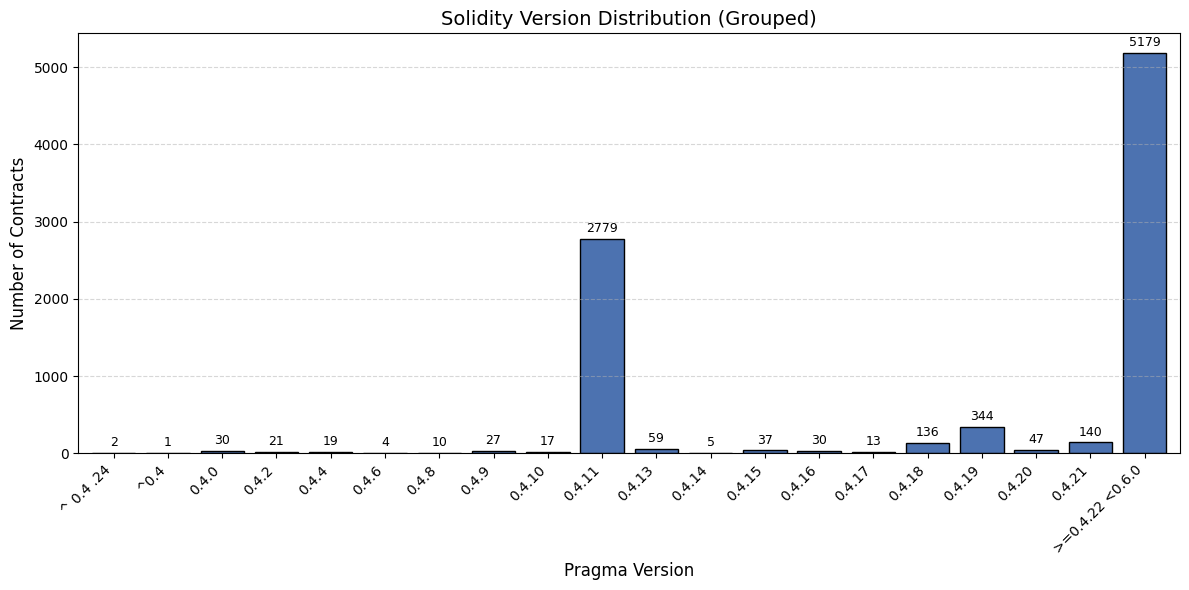

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import sys
import re

# Get the directory where this script is located (src/evaluation)
try:
    script_dir = os.path.dirname(os.path.abspath(__file__))
except NameError:
    script_dir = os.getcwd()

# Path to the CSV file generated previously
csv_path = os.path.join(script_dir, 'solidity_versions_summary.csv')

# --- INFERRED VERSION MAP ---
# Must match the logic used in copy_no_pragma.py to ensure consistency
version_map = {
    'IoU': '^0.4.11',
    'RE': '^0.4.11',
    'TD': '^0.4.24',
    'TD_source3': '^0.4.24',
    'RE_source3': '^0.4.24',
    'IoU_source3': '^0.4.24',
    'RE_full_source2_218': '^0.4.11',
    'smartbugs_RE': '^0.4.19',
    'TD_ESC': '^0.4.24', 
    'RE_smartbugs': '^0.4.19' 
}

def generate_chart():
    # 1. Load Data
    if not os.path.exists(csv_path):
        print(f"Error: Could not find {csv_path}")
        print("Please ensure you have generated the summary CSV first.")
        return

    print(f"Loading data from {csv_path}...")
    df = pd.read_csv(csv_path)

    # 2. Apply Inference Logic
    def fill_version(row):
        if row['Solidity_Version'] == 'Not Found':
            return version_map.get(row['Dataset_Folder'], 'Not Found')
        return row['Solidity_Version']

    df['Final_Version'] = df.apply(fill_version, axis=1)

    # --- NEW LOGIC: Normalize and Group ---
    
    # Helper to parse version numbers (0, 4, 24) from strings
    def get_version_tuple(v_str):
        match = re.search(r'(\d+)\.(\d+)\.(\d+)', str(v_str))
        if match:
            return tuple(map(int, match.groups()))
        return (0, 0, 0)

    def categorize_version(v_str):
        # 1. Get the base version numbers
        v_tuple = get_version_tuple(v_str)
        
        # 2. Check if it falls into the specific bucket: >=0.4.22 AND <0.6.0
        # (0, 4, 22) <= version < (0, 6, 0)
        if (0, 4, 22) <= v_tuple < (0, 6, 0):
            return ">=0.4.22 <0.6.0"
        
        # 3. If not in bucket, just normalize (remove ^)
        # Finds the first X.Y.Z pattern and returns it
        match = re.search(r'(\d+\.\d+\.\d+)', str(v_str))
        if match:
            return match.group(1)
            
        return v_str

    # Apply categorization
    df['Grouped_Version'] = df['Final_Version'].apply(categorize_version)

    # 3. Calculate Counts (Top 20)
    # Using the new Grouped_Version column
    top_versions = df['Grouped_Version'].value_counts().head(20)

    # Helper for sorting the categories
    def parse_version_for_sort(v_str):
        # Even for the category string ">=0.4.22 <0.6.0", this extracts (0, 4, 22)
        # which correctly places it after 0.4.21
        match = re.search(r'(\d+)\.(\d+)\.(\d+)', str(v_str))
        if match:
            return tuple(map(int, match.groups()))
        return (0, 0, 0)

    # Sort based on version number
    sorted_index = sorted(top_versions.index, key=parse_version_for_sort)
    version_counts = top_versions.reindex(sorted_index)
    
    print("\n--- Top Versions (Grouped & Sorted) ---")
    print(version_counts)

    # 4. Plotting
    plt.figure(figsize=(12, 6))
    
    # Create bar plot
    ax = version_counts.plot(kind='bar', color='#4c72b0', edgecolor='black', width=0.8)
    
    plt.title('Solidity Version Distribution', fontsize=14)
    plt.xlabel('Pragma Version', fontsize=12)
    plt.ylabel('Number of Contracts', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    
    # Add value labels on top of bars
    for i, v in enumerate(version_counts):
        ax.text(i, v + 50, str(v), ha='center', va='bottom', fontsize=9)

    plt.tight_layout()

    # 5. Save and Show
    output_image = os.path.join(script_dir, 'solidity_distribution_chart_grouped.png')
    plt.savefig(output_image, dpi=300)
    print(f"\nChart saved to: {output_image}")
    plt.show()

if __name__ == "__main__":
    generate_chart()

In [16]:
import os
import re
import pandas as pd

# --- CONFIGURATION ---
base_path = '../../data/preprocessed_data'

# Regex for version extraction
version_pattern = re.compile(r'pragma\s+solidity\s*([^;]+);', re.IGNORECASE)

# Regex to find the FIRST version number (e.g., 0.4.24) inside the string
number_extractor = re.compile(r'(\d+)\.(\d+)\.(\d+)')

extracted_data = []

print(f"Scanning directory: {base_path} ...")

for root, dirs, files in os.walk(base_path):
    for file in files:
        if file.endswith(".sol"):
            file_path = os.path.join(root, file)
            
            # --- EXTRACT VERSION ---
            sol_version_raw = "Unknown"
            category = "Unknown"
            
            try:
                with open(file_path, 'r', encoding='utf-8', errors='ignore') as f:
                    content = f.read()
                    match = version_pattern.search(content)
                    
                    if match:
                        sol_version_raw = match.group(1).strip()
                        
                        # Extract Major.Minor.Patch numbers
                        v_match = number_extractor.search(sol_version_raw)
                        
                        if v_match:
                            major = int(v_match.group(1))
                            minor = int(v_match.group(2))
                            patch = int(v_match.group(3))
                            
                            # --- CATEGORIZATION LOGIC ---
                            if major == 0 and minor == 4:
                                if patch < 11:
                                    category = '^0.4.0'
                                elif 11 <= patch < 19:
                                    category = '^0.4.11'
                                elif 19 <= patch < 22:
                                    category = '^0.4.19'
                                elif patch >= 22:
                                    category = '^0.4.22'
                            elif (major == 0 and minor >= 5) or major >= 1:
                                category = '>=0.4.22 <0.6.0'
                            else:
                                category = 'Unknown' # Fallback for weird versions like 0.3.x
                        else:
                            category = 'Unknown' # Pragma found but no numbers (e.g., imports)
                    else:
                        category = 'Unknown' # No pragma found at all

            except Exception as e:
                category = 'Unknown'

            extracted_data.append({
                'Category': category,
                'File_Name': file,
                'Raw_Version': sol_version_raw,
                'Full_Path': file_path
            })

# --- OUTPUT ---
df = pd.DataFrame(extracted_data)

# 1. Save detailed list (Optional, good for checking)
output_csv = 'solidity_versions_detailed.csv'
df.to_csv(output_csv, index=False)
print(f"Scanning complete. Processed {len(df)} files.")

# 2. Calculate Totals
# Define the exact order you requested
order = [
    '^0.4.0',
    '^0.4.11',
    '^0.4.19',
    '^0.4.22',
    '>=0.4.22 <0.6.0',
    'Unknown'
]

# Count the values
counts = df['Category'].value_counts().reindex(order, fill_value=0)

# Create the summary table
summary_df = pd.DataFrame({
    'Group': counts.index,
    'Total Count': counts.values
})

# Add a percentage column for better visibility
total_files = summary_df['Total Count'].sum()
summary_df['Percentage'] = (summary_df['Total Count'] / total_files * 100).round(2).astype(str) + '%'

print("\n--- Final Categorization Table ---")
print(summary_df.to_string(index=False))

# Save the summary table
summary_df.to_csv('final_category_counts.csv', index=False)
print("\nSummary saved to 'final_category_counts.csv'")

Scanning directory: ../../data/preprocessed_data ...
Scanning complete. Processed 8901 files.

--- Final Categorization Table ---
          Group  Total Count Percentage
         ^0.4.0          128      1.44%
        ^0.4.11          345      3.88%
        ^0.4.19          298      3.35%
        ^0.4.22          497      5.58%
>=0.4.22 <0.6.0          179      2.01%
        Unknown         7454     83.74%

Summary saved to 'final_category_counts.csv'


## 1447 - 1266 = 181 (1266 is the total contracts we mentioned in our paper that we used)

In [34]:
import os
import re
import pandas as pd
import matplotlib.pyplot as plt  # <-- added

# --- CONFIGURATION ---
base_path = '../../data/preprocessed_data'
no_pragma_base_path = '../../src/evaluation/no_pragma_contracts'  # <--- adjust if different

# Regex for version extraction
version_pattern = re.compile(r'pragma\s+solidity\s*([^;]+);', re.IGNORECASE)

# Regex to find the FIRST version number (e.g., 0.4.24) inside the string
number_extractor = re.compile(r'(\d+)\.(\d+)\.(\d+)')

extracted_data = []

print(f"Scanning directory (with pragma): {base_path} ...")

# ============================
# 1) CONTRACTS THAT HAVE PRAGMA
# ============================
for root, dirs, files in os.walk(base_path):
    for file in files:
        if not file.endswith(".sol"):
            continue

        file_path = os.path.join(root, file)

        try:
            with open(file_path, 'r', encoding='utf-8', errors='ignore') as f:
                content = f.read()
        except Exception:
            # If the file can't be read, skip it
            continue

        # --- EXTRACT VERSION ---
        match = version_pattern.search(content)

        # If there is NO pragma in the entire contract → skip (do NOT count)
        if not match:
            continue

        sol_version_raw = match.group(1).strip()

        # Extract Major.Minor.Patch numbers
        v_match = number_extractor.search(sol_version_raw)
        if not v_match:
            # Pragma exists but no proper version number → skip from counting
            continue

        major = int(v_match.group(1))
        minor = int(v_match.group(2))
        patch = int(v_match.group(3))

        # --- CATEGORIZATION LOGIC ---
        category = None

        if major == 0 and minor == 4:
            if patch < 11:
                category = '^0.4.0'
            elif 11 <= patch < 19:
                category = '^0.4.11'
            elif 19 <= patch < 22:
                category = '^0.4.19'
            elif patch >= 22:
                category = '^0.4.22'
        elif major == 0 and minor == 5:
            # All 0.5.x versions: >=0.4.22 and <0.6.0
            category = '>=0.4.22 <0.6.0'

        # If the version does not fall into any of the requested categories, skip it
        if category is None:
            continue

        extracted_data.append({
            'Category': category,
            'File_Name': file,
            'Raw_Version': sol_version_raw,
            'Full_Path': file_path
        })

print("Done scanning contracts with pragma.\n")

# ============================
# 2) NO-PRAGMA CONTRACTS FOLDER
# ============================

print(f"Scanning directory (no pragma contracts): {no_pragma_base_path} ...")

# Map folder names to categories
no_pragma_folder_to_category = {
    '^0.4.24': '>=0.4.22 <0.6.0',  # as you requested
    '^0.4.19': '^0.4.19',
    '^0.4.11': '^0.4.11'
}

if os.path.isdir(no_pragma_base_path):
    for folder_name in os.listdir(no_pragma_base_path):
        folder_path = os.path.join(no_pragma_base_path, folder_name)
        if not os.path.isdir(folder_path):
            continue

        category = no_pragma_folder_to_category.get(folder_name)
        if category is None:
            # Unknown category folder → skip (or print a warning)
            print(f"Warning: folder '{folder_name}' not in mapping; skipping.")
            continue

        # Walk recursively through this folder and count .sol files
        for root, dirs, files in os.walk(folder_path):
            for file in files:
                if not file.endswith(".sol"):
                    continue

                full_path = os.path.join(root, file)

                extracted_data.append({
                    'Category': category,
                    'File_Name': file,
                    # Use folder name as a pseudo-version tag for traceability
                    'Raw_Version': f'no_pragma_{folder_name}',
                    'Full_Path': full_path
                })
else:
    print(f"Warning: no_pragma_contracts directory '{no_pragma_base_path}' not found.")

# ============================
# 3) OUTPUT & SUMMARY
# ============================

df = pd.DataFrame(extracted_data)

# 1. Save detailed list (Optional, good for checking)
output_csv = 'solidity_versions_detailed_with_no_pragma.csv'
df.to_csv(output_csv, index=False)
print(f"\nScanning complete. Total counted files (with categories): {len(df)}")

# 2. Calculate Totals (only requested categories)
order = [
    '^0.4.0',
    '^0.4.11',
    '^0.4.19',
    '^0.4.22',
    '>=0.4.22 <0.6.0'
]

counts = df['Category'].value_counts().reindex(order, fill_value=0)

summary_df = pd.DataFrame({
    'Group': counts.index,
    'Total Count': counts.values
})

total_files = summary_df['Total Count'].sum()
if total_files > 0:
    summary_df['Percentage'] = (
        summary_df['Total Count'] / total_files * 100
    ).round(2).astype(str) + '%'
else:
    summary_df['Percentage'] = '0.00%'

print("\n--- Final Categorization Table (including no-pragma folders) ---")
print(summary_df.to_string(index=False))

summary_df.to_csv('final_category_counts_with_no_pragma.csv', index=False)
print("\nSummary saved to 'final_category_counts_with_no_pragma.csv'")

Scanning directory (with pragma): ../../data/preprocessed_data ...
Done scanning contracts with pragma.

Scanning directory (no pragma contracts): ../../src/evaluation/no_pragma_contracts ...

Scanning complete. Total counted files (with categories): 8897

--- Final Categorization Table (including no-pragma folders) ---
          Group  Total Count Percentage
         ^0.4.0          128      1.44%
        ^0.4.11         3063     34.43%
        ^0.4.19          523      5.88%
        ^0.4.22          497      5.59%
>=0.4.22 <0.6.0         4686     52.67%

Summary saved to 'final_category_counts_with_no_pragma.csv'



Chart saved to: /Users/fatemeh/Library/CloudStorage/OneDrive-polymtl/Drive/Fine_tune_Revision/code/FT_LLM_SCVD/src/evaluation/solidity_category_distribution_grouped.png


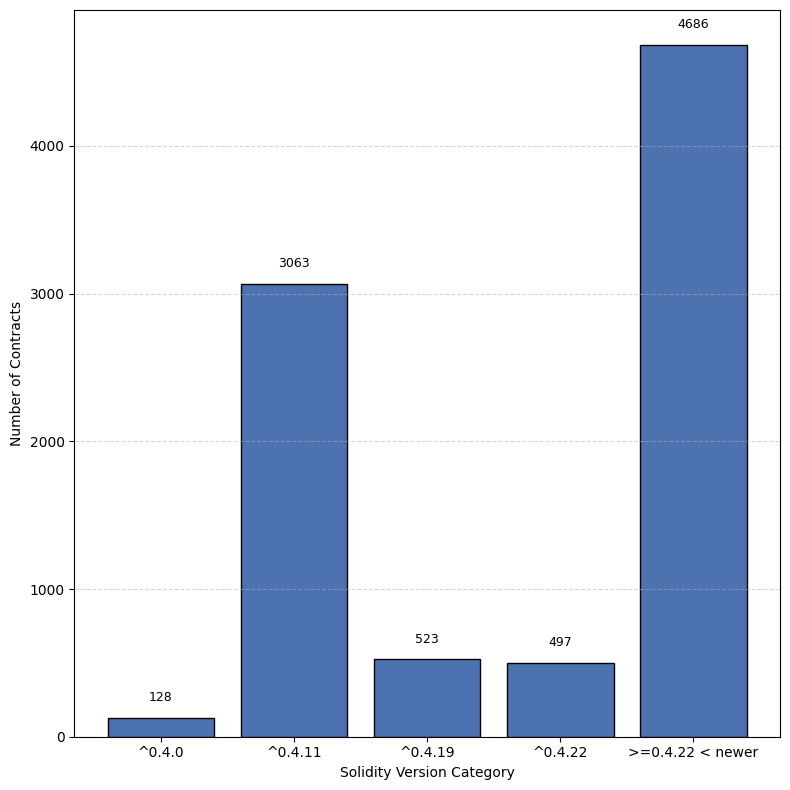

In [37]:
# ============================
# 4) PLOTTING
# ============================

# Use the counts Series for plotting (already in desired order)

version_counts = version_counts.rename(index={'>=0.4.22 <0.6.0': '>=0.4.22 < newer'})

plt.figure(figsize=(8, 8))

# Create bar plot (using your requested color)
ax = version_counts.plot(kind='bar', color='#4c72b0', edgecolor='black', width=0.8)

plt.title('', fontsize=10)
plt.xlabel('Solidity Version Category', fontsize=10)
plt.ylabel('Number of Contracts', fontsize=10)
plt.xticks(rotation=0, ha='center')
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Add value labels on top of bars
for i, v in enumerate(version_counts.values):
    ax.text(i, v + max(version_counts.max() * 0.02, 1), str(v),
            ha='center', va='bottom', fontsize=9)

plt.tight_layout()

# 5. Save and Show
# Safely determine script directory (works both in .py and notebook)
if '__file__' in globals():
    script_dir = os.path.dirname(os.path.abspath(__file__))
else:
    script_dir = os.getcwd()

output_image = os.path.join(script_dir, 'solidity_category_distribution_grouped.png')
plt.savefig(output_image, dpi=300)
print(f"\nChart saved to: {output_image}")
plt.show()

## The function-based dataset

In [20]:
import json
import os

base_path = '../fine-tuning/hugging-face/refineData/corrected_v1/splitting_function/corrected_v2'

files = [
    'functions_smart_test_data.json',
    'functions_smart_train_data.json',
    'functions_smart_valid_data.json'
]

for file in files:
    json_path = os.path.join(base_path, file)

    with open(json_path, 'r') as f:
        data = json.load(f)

    print(f"{file} length: {len(data)}")


functions_smart_test_data.json length: 1628
functions_smart_train_data.json length: 8462
functions_smart_valid_data.json length: 1200


## The contract-based dataset 

In [21]:
import json
import os

base_path = '../fine-tuning/hugging-face/refineData/corrected_v1/splitting_function'

files = [
    'vul_alpaca_test_data.json',
    'vul_alpaca_train_data.json',
    'vul_alpaca_valid_data.json'
]

for file in files:
    json_path = os.path.join(base_path, file)

    with open(json_path, 'r') as f:
        data = json.load(f)

    print(f"{file} length: {len(data)}")


vul_alpaca_test_data.json length: 191
vul_alpaca_train_data.json length: 949
vul_alpaca_valid_data.json length: 126


In [24]:
import os
import json

base_path = '../fine-tuning'

files = [
    'train_data.json',
    'test_data.json',
    'valid_data.json'
]

for file in files:
    json_path = os.path.join(base_path, file)

    with open(json_path, 'r') as f:
        #data = [json.loads(line) for line in f if line.strip()]
        data = json.load(f)
        
    print(f"{file} length: {len(data)}")


train_data.json length: 949
test_data.json length: 191
valid_data.json length: 126


## Final dataset jsonl:

In [27]:

import os
import json

base_path = '../../data/finetuning_data/'

files = [
    'final_dataset.jsonl'
]

for file in files:
    json_path = os.path.join(base_path, file)

    with open(json_path, 'r') as f:
        data = [json.loads(line) for line in f if line.strip()]
        #data = json.load(f)
        
    print(f"{file} length: {len(data)}")


final_dataset.jsonl length: 1266


In [1]:

import os
import json

base_path = '../../src/fine-tuning/hugging-face/refineData/corrected_v1/splitting_function/corrected_v2/'

files = [
    'functions_smart_test_data.json'
]

for file in files:
    json_path = os.path.join(base_path, file)

    with open(json_path, 'r') as f:
        #data = [json.loads(line) for line in f if line.strip()]
        data = json.load(f)
        
    print(f"{file} length: {len(data)}")

functions_smart_test_data.json length: 1628


### Starting comparison with slither, First providing new dataset suitable for Slither

In [6]:
import json
import os
import re
import sys

# --- CONFIGURATION ---
# We list multiple potential paths to be safe. The script will use the first one that exists.
POSSIBLE_PATHS = [
    # 1. If you are inside 'src/evaluation', this goes up to 'src' then into 'fine-tuning'
    '../fine-tuning/hugging-face/refineData/corrected_v1/splitting_function/corrected_v2/functions_smart_valid_data.json',
    
    # 2. The path you explicitly provided (in case you are running from a sibling folder like 'notebooks')
    '../src/fine-tuning/hugging-face/refineData/corrected_v1/splitting_function/corrected_v2/functions_smart_valid_data.json',
    
    # 3. Absolute path fallback (Assuming running from project root context)
    'src/fine-tuning/hugging-face/refineData/corrected_v1/splitting_function/corrected_v2/functions_smart_valid_data.json'
]

OUTPUT_DIR = 'comparison' # Saves directly to src/evaluation/comparison
OUTPUT_FILENAME = 'code_valid.json'

def find_input_file():
    """Checks the list of possible paths and returns the valid one."""
    print(f"Current Working Directory: {os.getcwd()}")
    
    for path in POSSIBLE_PATHS:
        # Resolve relative paths to absolute to verify
        abs_path = os.path.abspath(path)
        if os.path.exists(abs_path):
            print(f"Found input file at: {abs_path}")
            return abs_path
    
    # If we reach here, no file was found
    print("\nERROR: Could not find the input file in any of these locations:")
    for p in POSSIBLE_PATHS:
        print(f" - {os.path.abspath(p)}")
    return None

def extract_clean_code(input_text):
    if not input_text:
        return ""
    # 1. Isolate the code section (starts with "1:")
    match = re.search(r'\n\s*1:', input_text)
    if match:
        code_section = input_text[match.start():].lstrip() 
    else:
        code_section = input_text

    # 2. Remove line numbers
    line_number_pattern = re.compile(r'^\s*\d+:\s?')
    clean_lines = [line_number_pattern.sub('', line) for line in code_section.splitlines()]
    return '\n'.join(clean_lines).strip()

def main():
    # 1. Find the file
    input_path = find_input_file()
    if not input_path:
        return # Stop if not found

    # 2. Prepare Output
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    output_path = os.path.join(OUTPUT_DIR, OUTPUT_FILENAME)

    try:
        with open(input_path, 'r', encoding='utf-8') as f:
            data = json.load(f)
            
        print(f"Processing {len(data)} samples...")
        
        extracted_data = []
        for i, entry in enumerate(data):
            clean_code = extract_clean_code(entry.get('input', ''))
            extracted_data.append({
                "id": i,
                "code": clean_code,
                "ground_truth": entry.get('output', '')
            })
            
        with open(output_path, 'w', encoding='utf-8') as f:
            json.dump(extracted_data, f, indent=4)
            
        print(f"\nSUCCESS! File saved to: {os.path.abspath(output_path)}")
        print("You can now proceed to run the Slither evaluation script.")

    except Exception as e:
        print(f"An error occurred: {e}")

if __name__ == "__main__":
    main()

Current Working Directory: /Users/fatemeh/Library/CloudStorage/OneDrive-polymtl/Drive/Fine_tune_Revision/code/FT_LLM_SCVD/src/evaluation
Found input file at: /Users/fatemeh/Library/CloudStorage/OneDrive-polymtl/Drive/Fine_tune_Revision/code/FT_LLM_SCVD/src/fine-tuning/hugging-face/refineData/corrected_v1/splitting_function/corrected_v2/functions_smart_valid_data.json
Processing 1200 samples...

SUCCESS! File saved to: /Users/fatemeh/Library/CloudStorage/OneDrive-polymtl/Drive/Fine_tune_Revision/code/FT_LLM_SCVD/src/evaluation/comparison/code_valid.json
You can now proceed to run the Slither evaluation script.


## Install Slither

In [ ]:
!pip install slither-analyzer
!pip install solc-select  # Recommended to manage solidity versions
!solc-select install 0.8.0 # Install a compatible version
!solc-select use 0.8.0

In [17]:
import json
import os
import subprocess
import csv

# --- CONFIGURATION ---
INPUT_FILE_PATH = 'comparison/code_test.json'
SOL_OUTPUT_DIR = 'comparison/sol_files'
LABELS_OUTPUT_DIR = 'comparison/labels'
CSV_FILENAME = 'ground_truth.csv'

def parse_ground_truth(gt_data):
    """Parses the ground truth data to see if the sample is vulnerable."""
    try:
        data = gt_data
        if isinstance(gt_data, str):
            try:
                data = json.loads(gt_data)
            except json.JSONDecodeError:
                pass 

        if isinstance(data, dict):
            if 'vulnerableLines' in data:
                val = data['vulnerableLines']
                if isinstance(val, str) and val.strip() not in ["", "[]"]:
                    return True
                if isinstance(val, list) and len(val) > 0:
                    return True
            
            if 'vulnerableCode' in data:
                val = data['vulnerableCode']
                if isinstance(val, list) and len(val) > 0:
                    return True
        return False
    except Exception:
        return False

def save_sol_file(code_str, index):
    """Saves the code string to a .sol file."""
    # Ensure pragma exists for compatibility
    if "pragma solidity" not in code_str:
        code_str = "pragma solidity ^0.8.0;\n" + code_str

    filename = f"sample_{index}.sol"
    file_path = os.path.join(SOL_OUTPUT_DIR, filename)

    try:
        with open(file_path, 'w', encoding='utf-8') as f:
            f.write(code_str)
        return file_path, filename
    except Exception as e:
        print(f"Error saving {filename}: {e}")
        return None, None

def run_slither(file_path):
    """Runs Slither on the saved file path."""
    found_bug = False
    try:
        cmd = ['slither', file_path, '--json', '-']
        # Capture output, suppress stderr
        result = subprocess.run(cmd, capture_output=True, text=True)
        
        if result.stdout:
            try:
                output = json.loads(result.stdout)
                detectors = output.get('results', {}).get('detectors', [])
                if len(detectors) > 0:
                    found_bug = True
            except json.JSONDecodeError:
                pass
    except Exception:
        pass
    return found_bug

def main():
    # 1. Verify Input Path
    target_path = INPUT_FILE_PATH
    if not os.path.exists(target_path):
        # Fallback check
        if os.path.exists('src/evaluation/comparison/code_test.json'):
             target_path = 'src/evaluation/comparison/code_test.json'
        elif os.path.exists('code_test.json'):
             target_path = 'code_test.json'
        else:
            print(f"ERROR: Input file not found at '{INPUT_FILE_PATH}'")
            return

    # 2. Create Output Directories
    os.makedirs(SOL_OUTPUT_DIR, exist_ok=True)
    os.makedirs(LABELS_OUTPUT_DIR, exist_ok=True)

    print(f"Loading {target_path}...")
    with open(target_path, 'r') as f:
        data = json.load(f)

    print(f"Processing {len(data)} samples...")
    print(f" - Saving .sol files to: {SOL_OUTPUT_DIR}")
    print(f" - Saving CSV labels to: {LABELS_OUTPUT_DIR}/{CSV_FILENAME}")

    # 3. Setup CSV Writer
    csv_path = os.path.join(LABELS_OUTPUT_DIR, CSV_FILENAME)
    
    tp = 0; fp = 0; tn = 0; fn = 0

    with open(csv_path, 'w', newline='', encoding='utf-8') as csvfile:
        fieldnames = ['id', 'filename', 'is_vulnerable']
        writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
        writer.writeheader()

        for i, item in enumerate(data):
            code = item.get('code', '')
            gt_raw = item.get('ground_truth', '')
            
            # A. Parse Ground Truth
            is_vuln = parse_ground_truth(gt_raw)
            
            # B. Save .sol File
            saved_path, saved_filename = save_sol_file(code, i)
            
            # C. Save to CSV
            if saved_filename:
                writer.writerow({
                    'id': i,
                    'filename': saved_filename,
                    'is_vulnerable': is_vuln
                })
            
            # D. Run Slither (on the saved file)
            slither_vuln = False
            if saved_path:
                slither_vuln = run_slither(saved_path)
            
            # E. Calculate Metrics
            if is_vuln and slither_vuln: tp += 1
            elif not is_vuln and slither_vuln: fp += 1
            elif is_vuln and not slither_vuln: fn += 1
            else: tn += 1
                
            if (i + 1) % 100 == 0:
                print(f"Processed {i + 1} / {len(data)} samples...")

    # Metrics Output
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
    accuracy = (tp + tn) / len(data) if len(data) > 0 else 0.0

    print("\n" + "="*40)
    print("FINAL RESULTS")
    print("="*40)
    print(f"Saved .sol Files: {len(data)}")
    print(f"Saved Label CSV:  {csv_path}")
    print("-" * 40)
    print(f"Slither Accuracy:  {accuracy:.2%}")
    print(f"Slither Precision: {precision:.2%}")
    print(f"Slither Recall:    {recall:.2%}")
    print(f"Slither F1-Score:  {f1:.2%}")
    print("="*40)

if __name__ == "__main__":
    main()

Loading comparison/code_test.json...
Processing 1628 samples...
 - Saving .sol files to: comparison/sol_files
 - Saving CSV labels to: comparison/labels/ground_truth.csv
Processed 100 / 1628 samples...
Processed 200 / 1628 samples...
Processed 300 / 1628 samples...
Processed 400 / 1628 samples...
Processed 500 / 1628 samples...
Processed 600 / 1628 samples...
Processed 700 / 1628 samples...
Processed 800 / 1628 samples...
Processed 900 / 1628 samples...
Processed 1000 / 1628 samples...
Processed 1100 / 1628 samples...
Processed 1200 / 1628 samples...
Processed 1300 / 1628 samples...
Processed 1400 / 1628 samples...
Processed 1500 / 1628 samples...
Processed 1600 / 1628 samples...

FINAL RESULTS
Saved .sol Files: 1628
Saved Label CSV:  comparison/labels/ground_truth.csv
----------------------------------------
Slither Accuracy:  41.89%
Slither Precision: 0.00%
Slither Recall:    0.00%
Slither F1-Score:  0.00%


In [19]:
import json
import subprocess
import os

TARGET_SOL_FILE = "comparison/TimestampDependencyVulnerable.sol"
JSON_OUTPUT_FILE = "comparison/slither_timestamp.json"

def run_slither_timestamp_only(file_path):
    """Runs Slither on one file and checks for timestamp dependency."""
    if not os.path.exists(file_path):
        print("❌ File not found:", file_path)
        return False

    # Remove old JSON output if present
    if os.path.exists(JSON_OUTPUT_FILE):
        os.remove(JSON_OUTPUT_FILE)

    cmd = [
        "slither",
        file_path,
        "--detect", "timestamp",          # only timestamp-related issues
        "--json", JSON_OUTPUT_FILE        # write JSON to a file
    ]

    print("Running:", " ".join(cmd))
    result = subprocess.run(cmd, capture_output=True, text=True)

    if result.returncode != 0:
        print("❌ Slither returned an error code:", result.returncode)
        print("----- STDERR -----")
        print(result.stderr)
        return False

    if not os.path.exists(JSON_OUTPUT_FILE):
        print("⚠️ Slither finished but JSON file was not created.")
        print("----- STDERR -----")
        print(result.stderr)
        return False

    # Read JSON output
    with open(JSON_OUTPUT_FILE, "r", encoding="utf-8") as f:
        output = json.load(f)

    detectors = output.get("results", {}).get("detectors", [])
    if detectors:
        print("✅ Timestamp dependency (or related issues) detected!")
        for d in detectors:
            print(f"- Detector:  {d.get('check')}")
            print(f"  Impact:    {d.get('impact')}")
            print(f"  Confidence:{d.get('confidence')}")
        return True
    else:
        print("✅ No timestamp dependency reported by Slither.")
        return False


run_slither_timestamp_only(TARGET_SOL_FILE)


Running: slither comparison/TimestampDependencyVulnerable.sol --detect timestamp --json comparison/slither_timestamp.json
❌ Slither returned an error code: 1
----- STDERR -----
'solc --version' running
Traceback (most recent call last):
  File "/opt/homebrew/bin/slither", line 7, in <module>
    sys.exit(main())
  File "/opt/homebrew/lib/python3.10/site-packages/slither/__main__.py", line 776, in main
    main_impl(all_detector_classes=detectors, all_printer_classes=printers)
  File "/opt/homebrew/lib/python3.10/site-packages/slither/__main__.py", line 882, in main_impl
    ) = process_all(filename, args, detector_classes, printer_classes)
  File "/opt/homebrew/lib/python3.10/site-packages/slither/__main__.py", line 96, in process_all
    compilations = compile_all(target, **vars(args))
  File "/opt/homebrew/lib/python3.10/site-packages/crytic_compile/crytic_compile.py", line 722, in compile_all
    compilations.append(CryticCompile(target, **kwargs))
  File "/opt/homebrew/lib/python3.

False